In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

In [22]:
df = pd.read_csv('Data/UNHCR_Flow_Data_filtered.csv')
df.head()


,origin,OriginISO,OriginName,asylum,AsylumISO,AsylumName,AsylumRegion,PT,Year,Count
0,ANG,AGO,Angola,COD,COD,Dem. Rep. of the Congo,West and Central Africa,REF,1962,20000
1,ANG,AGO,Angola,NAM,NAM,Namibia,Eastern and Southern Africa,REF,1962,277
2,TIB,TIB,NaN,NEP,NPL,Nepal,Asia and the Pacific,REF,1962,2236
3,ANG,AGO,Angola,COD,COD,Dem. Rep. of the Congo,West and Central Africa,REF,1963,5000
4,ARE,EGY,Egypt,LEB,LBN,Lebanon,Middle East and North Africa,REF,1963,160


In [23]:
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Count"] = pd.to_numeric(df["Count"], errors="coerce")

df = df.dropna(subset=["Year", "Count"])
df["Year"] = df["Year"].astype(int)

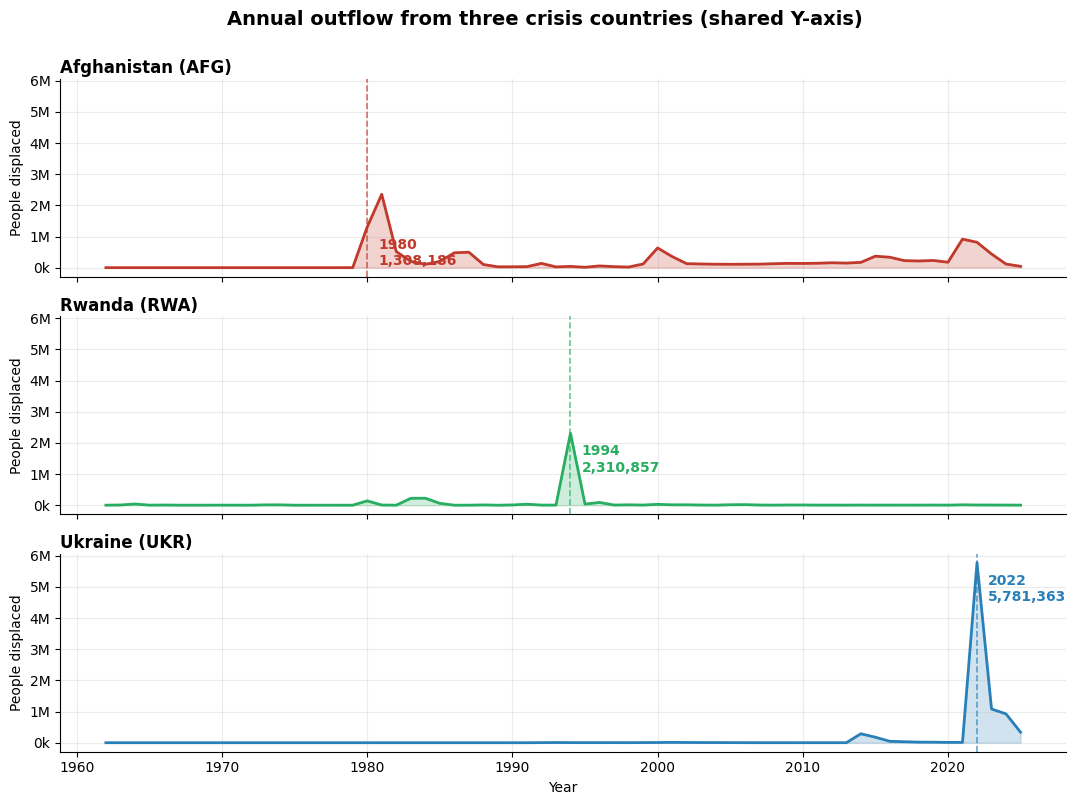

In [24]:
# Small multiples — outflow from each crisis country
CRISES = [
    ("AFG", "Afghanistan", 1980, "#c0392b"),
    ("RWA", "Rwanda",      1994, "#27ae60"),
    ("UKR", "Ukraine",     2022, "#2980b9"),
]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, sharey=True)

for ax, (iso, name, peak, color) in zip(axes, CRISES):
    series = (
        df[df["OriginISO"] == iso]
        .groupby("Year")["Count"].sum()
        .reindex(range(1962, 2026), fill_value=0)
    )
    ax.fill_between(series.index, series.values, color=color, alpha=0.22)
    ax.plot(series.index, series.values, color=color, linewidth=2)

    # mark the peak year for the crisis
    ax.axvline(peak, color=color, linestyle="--", linewidth=1.2, alpha=0.7)
    peak_val = series.loc[peak] if peak in series.index else 0
    ax.annotate(
        f"{peak}\n{int(peak_val):,}",
        xy=(peak, peak_val),
        xytext=(8, -8), textcoords="offset points",
        fontsize=10, fontweight="bold", color=color, va="top",
    )

    ax.set_title(f"{name} ({iso})", loc="left", fontsize=12, fontweight="bold", pad=4)
    ax.set_ylabel("People displaced")
    ax.grid(alpha=0.25)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    # human-readable Y ticks
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1e6)}M" if x >= 1e6 else f"{int(x/1e3)}k"))

axes[-1].set_xlabel("Year")
fig.suptitle("Annual outflow from three crisis countries (shared Y-axis)",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
plt.savefig("../visualizations/crisis_outflows.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
# Sankey — origin → top destinations for each crisis year
CRISES_SANKEY = [
    ("AFG", "Afghanistan", 1980),
    ("RWA", "Rwanda",      1994),
    ("UKR", "Ukraine",     2022),
]
TOP_K = 10

for iso, name, year in CRISES_SANKEY:
    flows = (
        df[(df["OriginISO"] == iso) & (df["Year"] == year)]
        .groupby("AsylumName", as_index=False)["Count"].sum()
        .sort_values("Count", ascending=False)
        .head(TOP_K)
    )

    if flows.empty:
        print(f"No data for {name} {year}")
        continue

    asylum_labels = flows["AsylumName"].fillna("Unknown").tolist()
    values        = flows["Count"].astype(int).tolist()
    total         = sum(values)

    labels = [f"{name} ({year})"] + asylum_labels
    source = [0] * len(asylum_labels)
    target = list(range(1, len(asylum_labels) + 1))

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=18, thickness=20,
            line=dict(color="black", width=0.4),
            label=labels,
            color=["#c0392b"] + ["#3498db"] * len(asylum_labels),
            hovertemplate="<b>%{label}</b><br>%{value:,} people<extra></extra>",
        ),
        link=dict(
            source=source, target=target, value=values,
            color="rgba(52, 152, 219, 0.4)",
            hovertemplate="<b>%{source.label} → %{target.label}</b><br>"
                          "%{value:,} people<extra></extra>",
        ),
    )])

    fig.update_layout(
        title=dict(
            text=f"<b>{name} {year}</b> — top {len(values)} destinations &nbsp;"
                 f"<span style='color:#7f8c8d;font-size:13px'>({total:,} people total)</span>",
            x=0.02, xanchor="left",
        ),
        font=dict(size=13, family="Arial"),
        height=480,
        margin=dict(l=20, r=20, t=70, b=20),
        paper_bgcolor="white",
    )

    fig.write_html(f"../visualizations/sankey_{iso.lower()}_{year}.html")
    fig.show()
